# Scenario Generation — 3 Circular + 3 Elliptical Supercells

Defines and saves the fixed benchmark scenario used by all subsequent notebooks.

- 3 **circular** supercells (TPV-style) with 2 sensitivity points each
- 3 **elliptical** supercells (jet-deformation zone)
- 2 rectangular obstacles
- Strict no-overlap: cell separation > extent_i + extent_j + 5 km

Run this notebook first. It writes `data/scenario_N6_seed42.pkl`.


In [1]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import time, itertools
from dataclasses import dataclass, field
from typing import List, Optional
from math import cos, sin, sqrt, pi, radians, degrees
from scipy.optimize import milp as sp_milp, LinearConstraint, Bounds
from scipy.sparse import csr_matrix

np.set_printoptions(precision=3, suppress=True)

# ── Geometry utilities ────────────────────────────────────────────────────
def uvec(a): return np.array([cos(a), sin(a)])
def rot2d(a):
    c,s=cos(a),sin(a); return np.array([[c,-s],[s,c]])
def cross2d(v,w): return float(v[0]*w[1]-v[1]*w[0])
def ensure_ccw(verts):
    pts=[np.asarray(v,float) for v in verts]
    area2=sum(pts[i][0]*pts[(i+1)%len(pts)][1]-pts[(i+1)%len(pts)][0]*pts[i][1]
              for i in range(len(pts)))
    return pts if area2>0 else pts[::-1]
def segments_intersect(p1,p2,p3,p4):
    EPS=1e-9; d1,d2=p2-p1,p4-p3; denom=cross2d(d1,d2)
    if abs(denom)<EPS: return False
    diff=p3-p1; t=cross2d(diff,d2)/denom; u=cross2d(diff,d1)/denom
    return EPS<t<1-EPS and EPS<u<1-EPS
def point_in_poly(pt,verts):
    EPS=1e-9
    for i in range(len(verts)):
        if cross2d(verts[(i+1)%len(verts)]-verts[i],pt-verts[i])<=EPS: return False
    return True
def seg_blocked(p1,p2,verts):
    for i in range(len(verts)):
        if segments_intersect(p1,p2,verts[i],verts[(i+1)%len(verts)]): return True
    return point_in_poly(0.5*(p1+p2),verts)
def path_len(w): return sum(np.linalg.norm(w[i+1]-w[i]) for i in range(len(w)-1))
def obs_free(start,end,verts):
    s,e=np.asarray(start,float),np.asarray(end,float)
    verts=[np.asarray(v,float) for v in verts]
    ok=lambda a,b: not seg_blocked(a,b,verts)
    if ok(s,e): return [s,e]
    n=len(verts); best,bd=None,float('inf')
    for v in verts:
        if ok(s,v) and ok(v,e):
            d=np.linalg.norm(v-s)+np.linalg.norm(e-v)
            if d<bd: bd,best=d,[s,v,e]
    for si in range(n):
        for ln in range(1,n):
            for arc in [[verts[(si+k)%n] for k in range(ln+1)],
                        [verts[(si-k)%n] for k in range(ln+1)]]:
                c=[s]+arc+[e]
                if all(ok(c[k],c[k+1]) for k in range(len(c)-1)):
                    d=path_len(c)
                    if d<bd: bd,best=d,c
    return best or [s,e]
def multi_obs(start,end,obstacles):
    if not obstacles: return [np.asarray(start,float),np.asarray(end,float)]
    cur=[np.asarray(start,float),np.asarray(end,float)]
    for obs in obstacles:
        obs=[np.asarray(v,float) for v in obs]; nw=[cur[0]]
        for i in range(len(cur)-1): nw.extend(obs_free(cur[i],cur[i+1],obs)[1:])
        cur=nw
    return cur
def transit_dist(p, q, obstacles):
    return path_len(multi_obs(p, q, obstacles))
print('Geometry utilities loaded.')


Geometry utilities loaded.


In [2]:
@dataclass
class CircularSupercell:
    center:np.ndarray; radius:float; L_max:float; weight:float; name:str
    sensitivity_points:List[np.ndarray]=field(default_factory=list)
    obstacle:Optional[List[np.ndarray]]=None
    def __post_init__(self):
        self.center=np.asarray(self.center,float)
        self.sensitivity_points=[np.asarray(s,float) for s in self.sensitivity_points]
        if self.obstacle is not None:
            self.obstacle=ensure_ccw([np.asarray(v,float) for v in self.obstacle])
    def cross_endpoints(self,theta,L):
        u1,u2=uvec(theta),uvec(theta+pi/2)
        return self.center-L*u1,self.center+L*u1,self.center-L*u2,self.center+L*u2
    def cross_blocked(self,theta,L):
        if self.obstacle is None: return False
        P0,P1,P2,P3=self.cross_endpoints(theta,L); c=self.center
        return any(seg_blocked(c,p,self.obstacle) for p in [P0,P1,P2,P3])

@dataclass
class EllipticalSupercell:
    center:np.ndarray; a:float; b:float; phi:float; weight:float; name:str
    obstacle:Optional[List[np.ndarray]]=None
    def __post_init__(self):
        self.center=np.asarray(self.center,float); self._R=rot2d(self.phi)
        if self.obstacle is not None:
            self.obstacle=ensure_ccw([np.asarray(v,float) for v in self.obstacle])
    def to_world(self,e): return self.center+self._R@np.asarray(e,float)
    def leg_halflen(self,xp,dt):
        if abs(xp)>=self.a: return None
        return self.b*sqrt(max(0.,1.-(xp/self.a)**2))+dt
    def leg_endpoints(self,xp,dt):
        L=self.leg_halflen(xp,dt)
        if L is None: return None
        return self.to_world(np.array([xp,-L])),self.to_world(np.array([xp,L]))
    def leg_positions(self,n,s): return [-(n-1)*s/2.+i*s for i in range(n)]
    def legs_valid(self,n,s): return all(abs(xp)<self.a for xp in self.leg_positions(n,s))

def compute_coverage(cell,xps,sw,gr=2.,ob=0.5):
    xa=np.arange(-cell.a-gr,cell.a+gr+0.1,gr); ya=np.arange(-cell.b-gr,cell.b+gr+0.1,gr)
    XX,YY=np.meshgrid(xa,ya); ins=(XX/cell.a)**2+(YY/cell.b)**2<=1.
    xp=np.array(xps,float); dx=np.abs(XX[:,:,None]-xp[None,None,:]); cov=(dx<=sw).sum(axis=2)
    ca=gr**2; cv=float((ins&(cov>=1)).sum()*ca); ov=float((ins*np.maximum(0,cov-1)).sum()*ca)
    return cv,ov
print('Dataclasses and coverage loaded.')


Dataclasses and coverage loaded.


In [3]:
# ── Scenario definition ──────────────────────────────────────────────────
# (Same scenario as the orienteering unit tests)
import os, pickle
os.makedirs('data', exist_ok=True); os.makedirs('figures', exist_ok=True)

BASE = np.array([50., 300.])

OBS1 = [[120., 340.], [200., 340.], [200., 430.], [120., 430.]]
OBS2 = [[310., 265.], [390., 265.], [390., 345.], [310., 345.]]
OBSTACLES = [OBS1, OBS2]

def sens_pt(center, r, angle_deg):
    return np.asarray(center, float) + (r + 12) * uvec(radians(angle_deg))

C1 = CircularSupercell(
    center=[220., 460.], radius=32., L_max=80., weight=1.8, name='C1',
    sensitivity_points=[sens_pt([220,460], 32, 315), sens_pt([220,460], 32, 225)],
    obstacle=OBS1)
C2 = CircularSupercell(
    center=[80., 110.], radius=28., L_max=75., weight=3.0, name='C2',
    sensitivity_points=[sens_pt([80,110], 28, 45), sens_pt([80,110], 28, 0)])
C3 = CircularSupercell(
    center=[480., 380.], radius=30., L_max=80., weight=2.0, name='C3',
    sensitivity_points=[sens_pt([480,380], 30, 180), sens_pt([480,380], 30, 135)],
    obstacle=OBS2)
E1 = EllipticalSupercell([390., 210.], a=55., b=32., phi=radians(15.),  weight=3.5, name='E1', obstacle=OBS2)
E2 = EllipticalSupercell([255., 120.], a=50., b=28., phi=radians(-10.), weight=2.5, name='E2')
E3 = EllipticalSupercell([480., 490.], a=52., b=30., phi=radians(20.),  weight=2.0, name='E3')

ALL_CELLS = [C1, C2, C3, E1, E2, E3]
N_CELLS   = len(ALL_CELLS)
labels    = ['BASE', 'C1', 'C2', 'C3', 'E1', 'E2', 'E3']

# Verify non-overlap
def cell_extent(c): return c.radius if isinstance(c, CircularSupercell) else c.a
for i in range(N_CELLS):
    for j in range(i+1, N_CELLS):
        ci, cj = ALL_CELLS[i], ALL_CELLS[j]
        d = np.linalg.norm(ci.center - cj.center)
        assert d > cell_extent(ci) + cell_extent(cj) + 5, f'{ci.name}–{cj.name} overlap!'
print('Non-overlap check PASSED.')

# Save
scenario = dict(BASE=BASE, OBSTACLES=OBSTACLES, cells=ALL_CELLS,
                labels=labels, N_CELLS=N_CELLS)
with open('data/scenario_N6_seed42.pkl', 'wb') as f:
    pickle.dump(scenario, f)
print('Saved → data/scenario_N6_seed42.pkl')
print()
print(f'{"Cell":>4}  {"Type":>10}  {"Weight":>6}  {"Center":>22}')
print('  ' + '-'*48)
for k, cell in enumerate(ALL_CELLS):
    ctype = 'Circular' if isinstance(cell, CircularSupercell) else 'Elliptical'
    print(f'  {labels[k+1]:4s}  {ctype:10s}  {cell.weight:6.1f}  {str(cell.center):>22s}')


Non-overlap check PASSED.
Saved → data/scenario_N6_seed42.pkl

Cell        Type  Weight                  Center
  ------------------------------------------------
  C1    Circular       1.8             [220. 460.]
  C2    Circular       3.0             [ 80. 110.]
  C3    Circular       2.0             [480. 380.]
  E1    Elliptical     3.5             [390. 210.]
  E2    Elliptical     2.5             [255. 120.]
  E3    Elliptical     2.0             [480. 490.]


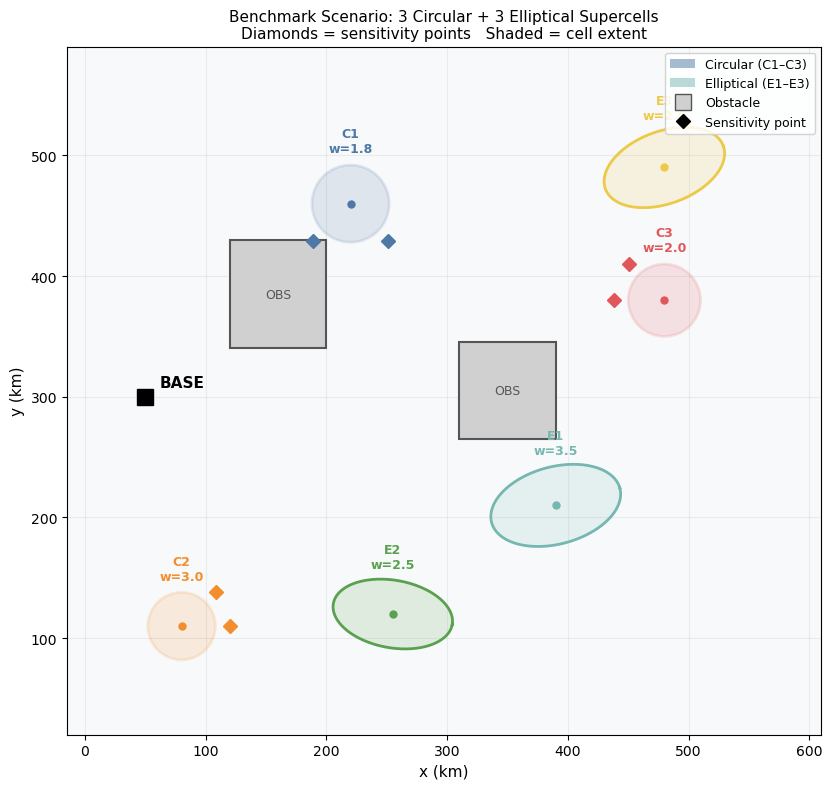

Figure saved → figures/scenario_overview.png


In [4]:
# ── Scenario visualisation ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))
ax.set_facecolor('#f8f9fa')

for obs in OBSTACLES:
    ax.add_patch(plt.Polygon(obs, closed=True,
                             facecolor='#d0d0d0', edgecolor='#555', lw=1.5, zorder=2))
    cx = np.mean([p[0] for p in obs]); cy = np.mean([p[1] for p in obs])
    ax.text(cx, cy, 'OBS', ha='center', va='center', fontsize=9, color='#555')

cell_colors = {'C1':'#4e79a7','C2':'#f28e2b','C3':'#e15759',
               'E1':'#76b7b2','E2':'#59a14f','E3':'#edc948'}
for k, cell in enumerate(ALL_CELLS):
    col = cell_colors[labels[k+1]]
    if isinstance(cell, CircularSupercell):
        ax.add_patch(plt.Circle(cell.center, cell.radius,
                                facecolor=col, alpha=0.15, edgecolor=col, lw=2, zorder=3))
        ax.plot(*cell.center, 'o', color=col, ms=5, zorder=4)
        for sp in cell.sensitivity_points:
            ax.plot(*sp, 'D', color=col, ms=7, zorder=5)
    else:
        th = np.linspace(0, 2*pi, 200)
        R_ = np.array([[cos(cell.phi),-sin(cell.phi)],[sin(cell.phi),cos(cell.phi)]])
        pts = (R_ @ np.vstack([cell.a*np.cos(th), cell.b*np.sin(th)])).T + cell.center
        ax.fill(pts[:,0], pts[:,1], color=col, alpha=0.15, zorder=2)
        ax.plot(pts[:,0], pts[:,1], color=col, lw=2, zorder=3)
        ax.plot(*cell.center, 'o', color=col, ms=5, zorder=4)
    ax.text(cell.center[0],
            cell.center[1] + (cell.radius if isinstance(cell,CircularSupercell) else cell.b) + 8,
            f'{cell.name}\nw={cell.weight}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=col)

ax.plot(*BASE, 'ks', ms=12, zorder=7)
ax.text(BASE[0]+12, BASE[1]+8, 'BASE', fontsize=11, fontweight='bold')
ax.set_xlim(-15, 610); ax.set_ylim(20, 590); ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.set_xlabel('x (km)', fontsize=11); ax.set_ylabel('y (km)', fontsize=11)
ax.set_title('Benchmark Scenario: 3 Circular + 3 Elliptical Supercells\n'
             'Diamonds = sensitivity points   Shaded = cell extent', fontsize=11)
import matplotlib.lines as mlines, matplotlib.patches as mpatch
handles = [
    mpatch.Patch(facecolor='#4e79a7', alpha=0.5, label='Circular (C1–C3)'),
    mpatch.Patch(facecolor='#76b7b2', alpha=0.5, label='Elliptical (E1–E3)'),
    mlines.Line2D([],[],color='#555',lw=0,marker='s',ms=12,
                  markerfacecolor='#d0d0d0',label='Obstacle'),
    mlines.Line2D([],[],color='black',lw=0,marker='D',ms=7,label='Sensitivity point'),
]
ax.legend(handles=handles, loc='upper right', fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.savefig('figures/scenario_overview.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('Figure saved → figures/scenario_overview.png')
